# Tarea 2

Nombre: Francico Gonzalez

Carnet: 24002914

In [1]:
import pandas as pd
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.preprocessing import PowerTransformer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#leer archivo dataTarea2.csv con pandas

df = pd.read_csv('dataTarea2.csv')


In [3]:


# Mostrar las primeras filas del dataset
print("Primeras filas del archivo:")
display(df.sample(25))

# Información general del DataFrame
print("Información general del dataset:")
print(df.info())



Primeras filas del archivo:


,Unnamed: 0,customer_id,gender,age,income,country,city,signup_channel,device_used,num_logins_last_month,...,loyalty_score,days_since_last_login,avg_basket_size,preferred_category,customer_support_calls,discount_usage_pct,referral_count,review_score,registration_date,last_purchase_date
60,60,61,Male,23,79312.361506,Australia,London,Referral,Mobile,4,...,56.247534,358,2.700306,Fashion,2,53.723191,1,5.000000,2021-06-23,2021-09-13
541,541,542,Female,39,56381.672963,Canada,London,Referral,Desktop,10,...,99.270116,257,5.544023,Books,1,90.557850,0,4.825098,2021-09-12,2023-08-25
961,961,962,Female,42,55272.198505,Canada,Los Angeles,Web,Mobile,6,...,55.810238,347,5.751853,Home,2,91.733392,1,3.191213,2020-01-04,2020-04-24
883,883,884,Male,36,33839.358845,UK,Madrid,Mobile,Desktop,6,...,94.650600,120,1.943880,Electronics,1,77.933744,0,3.525224,2022-02-26,2022-09-20
452,452,453,Male,43,45487.103793,Spain,New York,Mobile,Desktop,13,...,18.364385,78,1.000000,Books,0,16.823212,0,4.874538,2021-10-28,2022-01-25
640,640,641,Male,54,55078.293144,UK,Paris,Web,Desktop,8,...,74.760467,73,6.582156,Electronics,1,39.428870,0,4.846628,2022-04-25,2023-09-05
1150,1150,1151,Female,31,35092.059877,France,Los Angeles,Web,Tablet,16,...,6.838112,106,3.943570,Beauty,0,55.867848,1,5.000000,2020-10-05,2020-10-28
871,871,872,Male,25,77865.535153,USA,Berlin,Referral,Desktop,11,...,60.227748,262,5.785966,Fashion,0,14.213099,0,2.260840,2020-07-06,2022-04-12
1045,1045,1046,Female,39,54614.190023,UK,Berlin,Referral,Mobile,16,...,10.288681,109,7.107365,Home,1,51.466354,0,3.115351,2020-05-21,2020-09-07
1383,1383,1384,Male,31,54494.715318,Australia,Los Angeles,Web,Tablet,8,...,76.301799,15,4.815029,Fashion,0,64.358828,0,4.897373,2020-03-25,2020-06-27


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              1500 non-null   int64  
 1   customer_id             1500 non-null   int64  
 2   gender                  1500 non-null   object 
 3   age                     1500 non-null   int64  
 4   income                  1500 non-null   float64
 5   country                 1500 non-null   object 
 6   city                    1500 non-null   object 
 7   signup_channel          1500 non-null   object 
 8   device_used             1500 non-null   object 
 9   num_logins_last_month   1500 non-null   int64  
 10  avg_session_time_min    1500 non-null   float64
 11  purchases_last_month    1500 non-null   int64  
 12  total_spent             1500 non-null   float64
 13  loyalty_score           1500 non-null   float64
 14  days_si

In [4]:


# Eliminar columna redundante si solo es el índice
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Convertir columnas a tipo categórico
categorical_cols = [
    'gender',
    'country',
    'city',
    'signup_channel',
    'device_used',
    'preferred_category'
]
df[categorical_cols] = df[categorical_cols].astype('category')

# Convertir fechas a tipo datetime
df['registration_date'] = pd.to_datetime(df['registration_date'], errors='coerce')
df['last_purchase_date'] = pd.to_datetime(df['last_purchase_date'], errors='coerce')

# Confirmar los nuevos tipos de datos
print("Tipos de datos actualizados:")
print(df.dtypes)


Tipos de datos actualizados:
customer_id                        int64
gender                          category
age                                int64
income                           float64
country                         category
city                            category
signup_channel                  category
device_used                     category
num_logins_last_month              int64
avg_session_time_min             float64
purchases_last_month               int64
total_spent                      float64
loyalty_score                    float64
days_since_last_login              int64
avg_basket_size                  float64
preferred_category              category
customer_support_calls             int64
discount_usage_pct               float64
referral_count                     int64
review_score                     float64
registration_date         datetime64[ns]
last_purchase_date        datetime64[ns]
dtype: object


In [5]:
# Estadísticas descriptivas para variables numéricas
print("Estadísticas descriptivas (numéricas):")
display(df.describe(include=['int64', 'float64']))

# Estadísticas descriptivas para variables categóricas
print("Estadísticas descriptivas (categóricas):")
display(df.describe(include=['category']))

# Estadísticas de fechas (mínimo y máximo)
print("Fechas (mínimo y máximo):")
for col in df.select_dtypes(include='datetime64[ns]').columns:
    print(f"{col}: min = {df[col].min()}, max = {df[col].max()}")
print()

# Verificar valores nulos por tipo
print("Valores nulos (por tipo de variable):")

print("Numéricas:")
print(df.select_dtypes(include=['int64', 'float64']).isnull().sum())

print("Categóricas:")
print(df.select_dtypes(include='category').isnull().sum())

print("Fechas:")
print(df.select_dtypes(include='datetime64[ns]').isnull().sum())

# Valores únicos por columna categórica
print("Valores únicos por columna categórica:")
for col in df.select_dtypes(include='category').columns:
    print(f"\n{col}:")
    print(df[col].unique())


Estadísticas descriptivas (numéricas):


,customer_id,age,income,num_logins_last_month,avg_session_time_min,purchases_last_month,total_spent,loyalty_score,days_since_last_login,avg_basket_size,customer_support_calls,discount_usage_pct,referral_count,review_score
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,750.500000,34.977333,53503.766436,10.055333,15.063060,2.960667,524.898158,50.285258,177.740667,5.029068,0.953333,50.072905,0.490667,3.942974
std,433.157015,9.495311,42809.749464,3.109778,5.037192,1.740059,536.312223,28.862484,107.044267,1.945164,0.957654,29.155957,0.702074,0.842347
min,1.000000,18.000000,5132.960436,2.000000,1.000000,0.000000,-3598.214824,0.191571,0.000000,1.000000,0.000000,0.006750,0.000000,1.000000
25%,375.750000,28.000000,39363.110468,8.000000,11.655301,2.000000,292.105275,24.790611,86.000000,3.605114,0.000000,24.316144,0.000000,3.344802
50%,750.500000,35.000000,49979.618649,10.000000,15.120441,3.000000,491.967577,50.588096,173.000000,5.018855,1.000000,49.589915,0.000000,4.019240
75%,1125.250000,41.000000,60184.028217,12.000000,18.486887,4.000000,694.991588,74.819680,268.000000,6.358923,1.000000,75.123145,1.000000,4.667903
max,1500.000000,66.000000,676949.950074,20.000000,32.093061,12.000000,8597.880545,99.977448,364.000000,12.805597,6.000000,99.969721,4.000000,5.000000


Estadísticas descriptivas (categóricas):


,gender,country,city,signup_channel,device_used,preferred_category
count,1500,1500,1500,1500,1500,1500
unique,3,7,7,4,3,6
top,Female,Canada,Los Angeles,Web,Tablet,Toys
freq,676,245,229,427,525,264


Fechas (mínimo y máximo):
registration_date: min = 2020-01-02 00:00:00, max = 2022-09-26 00:00:00
last_purchase_date: min = 2020-01-20 00:00:00, max = 2025-01-30 00:00:00

Valores nulos (por tipo de variable):
Numéricas:
customer_id               0
age                       0
income                    0
num_logins_last_month     0
avg_session_time_min      0
purchases_last_month      0
total_spent               0
loyalty_score             0
days_since_last_login     0
avg_basket_size           0
customer_support_calls    0
discount_usage_pct        0
referral_count            0
review_score              0
dtype: int64
Categóricas:
gender                0
country               0
city                  0
signup_channel        0
device_used           0
preferred_category    0
dtype: int64
Fechas:
registration_date     0
last_purchase_date    0
dtype: int64
Valores únicos por columna categórica:

gender:
['Male', 'Other', 'Female']
Categories (3, object): ['Female', 'Male', 'Other']

countr

In [6]:
# Seleccionar columnas numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Aplicar escalados
minmax_scaled = pd.DataFrame(MinMaxScaler().fit_transform(df[num_cols]), columns=num_cols)
zscore_scaled = pd.DataFrame(StandardScaler().fit_transform(df[num_cols]), columns=num_cols)
robust_scaled = pd.DataFrame(RobustScaler().fit_transform(df[num_cols]), columns=num_cols)

# Mostrar ejemplos
print("MinMax Scaling (0 a 1):")
display(minmax_scaled.sample(25))

print("Z-Score Scaling (media 0, std 1):")
display(zscore_scaled.sample(25))

print("Robust Scaling (mediana, IQR):")
display(robust_scaled.sample(25))

MinMax Scaling (0 a 1):


,customer_id,age,income,num_logins_last_month,avg_session_time_min,purchases_last_month,total_spent,loyalty_score,days_since_last_login,avg_basket_size,customer_support_calls,discount_usage_pct,referral_count,review_score
1179,0.786524,0.208333,0.059856,0.277778,0.499403,0.333333,0.324581,0.078511,0.293956,0.412834,0.000000,0.602255,0.00,0.790733
862,0.575050,0.625000,0.045224,0.277778,0.564021,0.166667,0.354532,0.131284,0.607143,0.384645,0.500000,0.426173,0.00,0.777773
1208,0.805871,0.104167,0.069908,0.222222,0.269330,0.166667,0.354113,0.264905,0.846154,0.274363,0.000000,0.706247,0.00,0.266005
555,0.370247,0.333333,0.106568,0.444444,0.374160,0.166667,0.323010,0.900912,0.145604,0.225318,0.333333,0.694394,0.25,1.000000
441,0.294196,0.625000,0.085887,0.611111,0.558314,0.333333,0.359154,0.491921,0.390110,0.248554,0.666667,0.346825,0.00,0.898648
925,0.617078,0.083333,0.037904,0.277778,0.206968,0.166667,0.368915,0.167311,0.217033,0.383887,0.166667,0.288909,0.25,0.856894
1489,0.993329,0.541667,0.072222,0.777778,0.628482,0.083333,0.324678,0.724971,0.250000,0.456281,0.333333,0.469528,0.25,0.672584
1175,0.783856,0.458333,0.057908,0.277778,0.616205,0.250000,0.349582,0.844588,0.450549,0.361164,0.000000,0.652019,0.00,0.798145
1492,0.995330,0.458333,0.068707,0.500000,0.265625,0.333333,0.343138,0.841232,0.351648,0.386872,0.000000,0.518037,0.25,0.755388
665,0.443629,0.437500,0.077394,0.111111,0.537527,0.500000,0.324177,0.531983,0.228022,0.706525,0.333333,0.815676,0.00,0.568870


Z-Score Scaling (media 0, std 1):


,customer_id,age,income,num_logins_last_month,avg_session_time_min,purchases_last_month,total_spent,loyalty_score,days_since_last_login,avg_basket_size,customer_support_calls,discount_usage_pct,referral_count,review_score
462,-0.663953,0.950540,0.090298,0.303874,-0.591423,-0.552273,0.181906,-1.097399,-0.988151,0.335399,-0.995821,0.566352,-0.699115,1.255277
886,0.315233,0.002388,0.158947,0.947222,0.050271,1.747267,0.645938,0.200627,-0.362033,0.034834,0.048746,-0.296747,-0.699115,0.688663
933,0.423775,-1.261815,-0.600424,1.912242,0.168507,-0.552273,-0.585874,-1.397886,0.890203,-0.063317,-0.995821,-0.438875,0.725711,0.764536
623,-0.292139,0.739840,0.225329,1.268895,1.297217,0.022612,0.629895,-1.068066,-0.483519,0.524218,1.093314,0.085387,-0.699115,0.796562
287,-1.068098,0.529139,-1.130278,0.303874,0.235521,-0.552273,0.707614,0.654531,-1.586234,-0.843462,0.048746,1.600362,0.725711,1.255277
1259,1.176640,-1.472516,-0.102698,-0.017799,0.881581,-0.552273,0.809455,0.581507,-1.567544,-2.028726,1.093314,1.247846,0.725711,-2.336447
230,-1.199734,0.423789,-0.032361,0.625548,-0.780390,0.597497,-1.999189,-1.610104,1.563046,-0.719708,1.093314,1.378231,-0.699115,-0.963567
744,-0.012702,-0.208313,0.070939,-0.982820,1.268960,1.172382,0.054975,-1.329025,-0.548934,-0.280545,-0.995821,1.691344,-0.699115,0.514638
626,-0.285211,-0.419013,-0.197581,-0.339473,2.364749,1.747267,-0.377599,-0.573378,-1.240468,2.827403,-0.995821,-0.956931,0.725711,1.121458
205,-1.257469,-0.208313,-0.189761,-0.661147,0.157857,-1.127158,-0.202730,-0.680741,0.077184,0.656180,0.048746,1.077830,0.725711,0.148300


Robust Scaling (mediana, IQR):


,customer_id,age,income,num_logins_last_month,avg_session_time_min,purchases_last_month,total_spent,loyalty_score,days_since_last_login,avg_basket_size,customer_support_calls,discount_usage_pct,referral_count,review_score
27,-0.963976,-0.230769,-1.105292,2.00,0.022379,0.0,0.117488,0.629274,0.131868,0.053619,-1.0,-0.385118,0.0,0.738362
668,-0.108739,-0.076923,-0.785848,0.00,0.009074,-0.5,0.337273,0.952777,0.609890,0.820984,0.0,0.813342,1.0,0.358325
1113,0.484990,0.000000,-0.546334,0.75,-1.146553,0.5,-0.335379,-0.365792,0.362637,0.718952,-1.0,-0.182866,1.0,-0.144812
803,0.071381,0.461538,0.738360,0.75,-0.048201,1.0,0.584616,-0.802882,0.170330,0.619219,0.0,-0.363729,0.0,0.741259
1377,0.837225,0.692308,-0.158606,2.00,-0.532916,0.0,-1.376364,0.138894,-0.054945,-0.884356,0.0,0.739228,0.0,-0.199004
1296,0.729153,-0.461538,-0.065981,-0.25,0.749641,-1.0,-1.258088,0.931970,0.467033,0.430052,0.0,0.070122,0.0,-0.263989
472,-0.370247,-0.538462,-1.246229,0.00,-0.192564,1.5,0.048302,0.231852,0.500000,0.092869,-1.0,-0.356268,0.0,0.631110
1184,0.579720,-1.307692,1.159992,0.75,0.925143,1.5,0.339115,-0.272272,0.027473,-0.912705,-1.0,0.328765,0.0,-0.957526
746,-0.004670,-1.230769,0.492362,-0.25,-0.380774,0.0,0.382559,0.191061,-0.247253,0.419847,0.0,0.111165,1.0,-1.350412
1109,0.479653,-0.076923,-0.397362,-0.50,-0.320095,-1.5,0.915416,-0.029114,0.417582,-0.277740,-1.0,-0.154816,0.0,-0.919169


In [7]:
# Seleccionar columnas numéricas
num_df = df.select_dtypes(include=['int64', 'float64'])

# Aplicar transformaciones solo si todos los valores cumplen los requisitos
log_transformed = np.log1p(num_df.clip(lower=0))
sqrt_transformed = np.sqrt(num_df.clip(lower=0))

# Box-Cox solo para valores estrictamente positivos
boxcox_df = num_df[num_df.columns[(num_df > 0).all()]]
boxcox_transformed = pd.DataFrame(
    PowerTransformer(method='box-cox').fit_transform(boxcox_df),
    columns=boxcox_df.columns
)

# Yeo-Johnson (soporta negativos)
yeojohnson_transformed = pd.DataFrame(
    PowerTransformer(method='yeo-johnson').fit_transform(num_df),
    columns=num_df.columns
)

# Mostrar ejemplos
print("Transformación Logarítmica (log1p):")
display(log_transformed.sample(25))

print("Transformación Raíz Cuadrada:")
display(sqrt_transformed.sample(25))

print("Transformación Box-Cox (solo positivos):")
display(boxcox_transformed.sample(25))

print("Transformación Yeo-Johnson:")
display(yeojohnson_transformed.sample(25))


Transformación Logarítmica (log1p):


,customer_id,age,income,num_logins_last_month,avg_session_time_min,purchases_last_month,total_spent,loyalty_score,days_since_last_login,avg_basket_size,customer_support_calls,discount_usage_pct,referral_count,review_score
970,6.879356,3.688879,10.984404,2.564949,3.037145,0.000000,5.079699,2.224679,5.389072,2.016124,0.693147,4.308874,0.000000,1.536518
853,6.751101,3.258097,10.076871,2.772589,2.479065,1.098612,6.352352,4.119714,5.556828,1.970291,0.693147,3.974362,0.000000,1.546408
1174,7.069874,3.784190,10.475854,2.639057,3.101428,1.609438,6.186435,4.197378,5.468060,1.665401,0.693147,4.022252,0.000000,1.749602
112,4.736198,3.218876,10.765309,2.397895,2.462474,0.693147,6.084587,3.498052,5.575949,1.621523,0.000000,4.208192,0.000000,0.693147
1190,7.083388,3.828641,10.648541,2.302585,2.987882,1.609438,4.747001,4.027968,5.749393,1.784279,0.693147,3.629341,0.000000,1.552828
1159,7.057037,3.178054,10.380980,1.791759,2.539416,1.609438,6.910565,3.425606,5.049856,2.270750,0.000000,4.198103,0.000000,1.791759
460,6.135565,3.610918,10.663068,2.708050,2.251648,1.791759,5.571194,3.382641,5.252273,1.894341,0.000000,2.102934,0.000000,1.791759
273,5.616771,3.401197,11.071789,2.564949,2.014913,1.098612,5.628472,3.925563,5.170484,1.507346,0.000000,2.826470,0.000000,1.094245
785,6.668228,3.465736,10.400798,2.890372,3.126787,1.098612,6.871356,3.924280,4.304065,1.763848,0.693147,4.562501,0.000000,1.714897
1389,7.237778,4.025352,10.931330,1.945910,2.438768,1.386294,5.542121,4.309065,4.927254,1.812667,1.098612,3.610821,0.000000,1.497081


Transformación Raíz Cuadrada:


,customer_id,age,income,num_logins_last_month,avg_session_time_min,purchases_last_month,total_spent,loyalty_score,days_since_last_login,avg_basket_size,customer_support_calls,discount_usage_pct,referral_count,review_score
1379,37.148351,5.916080,199.165049,3.000000,3.792968,2.236068,23.444503,3.216697,1.414214,1.520733,1.000000,5.434549,0.000000,2.236068
372,19.313208,6.164414,238.333025,2.449490,3.482441,2.236068,15.161959,3.298003,6.928203,2.316794,1.000000,9.913274,1.000000,1.777492
560,23.685439,6.324555,185.061852,3.464102,3.865419,2.000000,12.851385,9.057380,11.224972,2.903472,1.414214,4.782313,0.000000,1.801030
863,29.393877,4.582576,272.832358,3.000000,3.586728,1.414214,29.206195,6.879973,18.681542,1.786819,0.000000,4.226606,0.000000,2.236068
1313,36.249138,4.582576,226.496061,2.828427,4.414067,2.000000,21.982126,8.438987,18.734994,2.630318,1.414214,8.075833,0.000000,1.993503
255,16.000000,6.633250,278.799449,2.828427,3.592224,0.000000,0.000000,4.806814,8.774964,1.962238,0.000000,3.944212,1.000000,2.236068
658,25.670995,5.656854,258.510866,3.316625,4.979152,1.414214,28.600163,9.431724,16.000000,2.160984,0.000000,7.314624,1.414214,1.965743
323,18.000000,5.567764,233.089800,3.000000,4.279763,1.414214,11.310945,3.824820,17.521415,1.715977,1.000000,9.928172,1.000000,2.170324
901,30.033315,5.744563,196.592320,2.645751,3.491528,1.000000,24.363844,7.798303,5.830952,2.609297,1.414214,4.094881,1.000000,2.041687
1339,36.606010,6.164414,235.392690,2.645751,3.689631,1.000000,0.000000,9.747141,14.491377,1.910717,0.000000,9.830439,0.000000,2.160251


Transformación Box-Cox (solo positivos):


,customer_id,age,income,num_logins_last_month,avg_session_time_min,loyalty_score,avg_basket_size,discount_usage_pct,review_score
95,-1.661389,-1.425525,-0.237125,-1.340276,-1.139737,1.243363,0.364590,0.655623,-1.336314
267,-1.089454,-1.300536,0.261458,-1.340276,-1.550472,-1.230176,-0.751455,-1.445966,1.384367
150,-1.459095,-0.046820,0.027411,1.810774,2.515924,-1.378192,-0.196814,-1.840484,0.496725
605,-0.223192,-0.938175,1.189152,0.028559,-0.424310,-0.176633,-0.471991,1.095966,-0.511401
1065,0.747920,1.329095,0.495119,0.650368,2.250818,-1.318812,1.273518,-0.655196,0.884786
1047,0.712601,0.366536,0.915163,0.028559,-0.256298,0.910833,0.887687,-0.665738,0.127484
1255,1.110830,0.264921,0.045894,0.949819,-0.044175,-0.210889,0.163345,-0.110784,1.384367
812,0.233578,0.665067,0.149848,2.358590,1.368141,-2.101858,1.162666,-0.374561,-0.681428
802,0.212360,0.566572,0.222243,-0.630725,1.103902,-1.788406,0.041973,-1.490170,-1.369307
197,-1.303095,0.366536,-0.058971,-0.978115,-1.891266,-1.431346,-0.917630,0.964515,0.956682


Transformación Yeo-Johnson:


,customer_id,age,income,num_logins_last_month,avg_session_time_min,purchases_last_month,total_spent,loyalty_score,days_since_last_login,avg_basket_size,customer_support_calls,discount_usage_pct,referral_count,review_score
793,0.192401,-0.706431,-0.330409,0.950722,0.148910,-0.468079,-1.467420,1.337046,-0.298410,0.167143,-1.180867,0.761359,1.149930,1.140542
7,-2.096969,0.566552,-1.010622,-1.341961,-1.021501,-1.184055,0.091717,0.817867,0.664135,-0.723183,-1.180867,0.499135,1.696853,-0.850914
1222,1.049567,0.366402,-1.874612,-1.341961,1.807719,-0.468079,0.935115,-0.092223,0.617018,3.598636,0.329315,-0.591573,-0.798102,0.223725
841,0.294005,-0.153571,-0.389499,-0.295843,-1.053432,-1.184055,0.480498,1.417354,-1.814326,-1.520910,0.329315,1.269912,1.149930,-0.108354
515,-0.436825,-0.370370,-0.504701,0.029026,0.573930,0.666891,0.074028,-0.439635,0.687546,0.691172,-1.180867,1.400412,1.149930,0.811687
1052,0.722374,0.859332,0.305432,0.029026,0.116449,0.135357,0.356100,-0.749874,0.749516,0.400588,-1.180867,1.465325,-0.798102,1.392663
861,0.335843,0.264730,-3.367357,0.651365,-0.995871,-0.468079,0.015127,0.033040,-0.749224,-1.881214,1.129102,-1.365175,-0.798102,1.392663
1343,1.274443,-0.706431,0.427789,-0.295843,-0.034197,0.135357,0.557166,0.580512,0.609127,1.344654,1.129102,-0.677492,-0.798102,-0.814394
518,-0.429577,0.955070,0.719566,0.029026,0.726177,1.147361,-0.397718,-0.795205,-0.598971,0.193608,0.329315,0.843806,-0.798102,1.392663
1081,0.779212,0.566552,0.457796,1.529399,-0.315027,0.135357,-0.078210,-0.603775,0.112491,-0.526626,-1.180867,-1.873174,1.149930,-1.804818


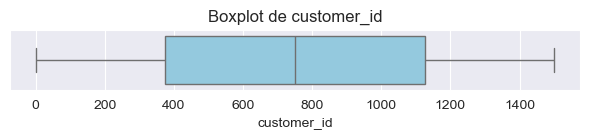

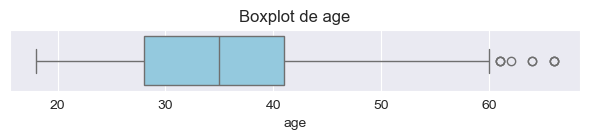

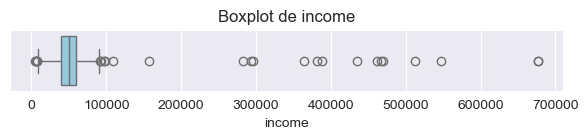

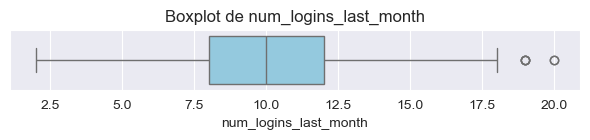

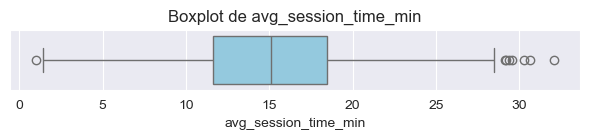

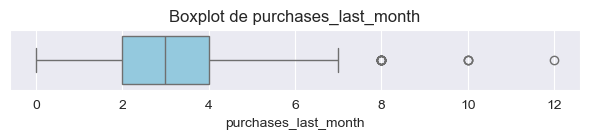

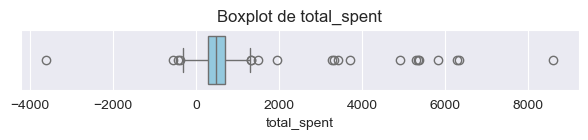

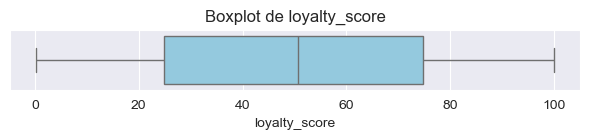

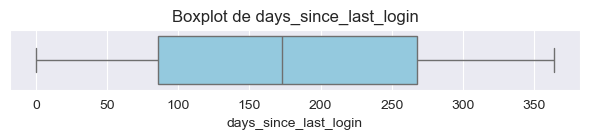

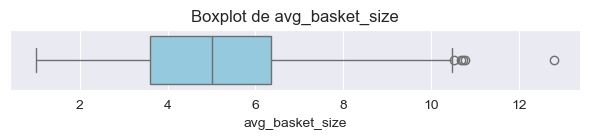

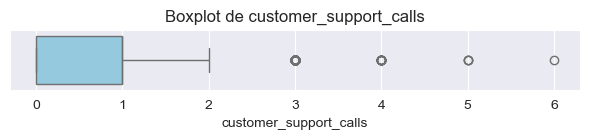

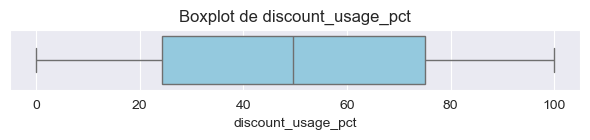

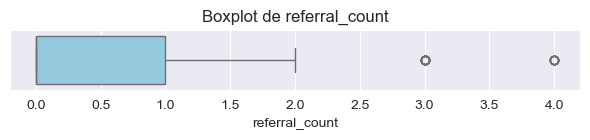

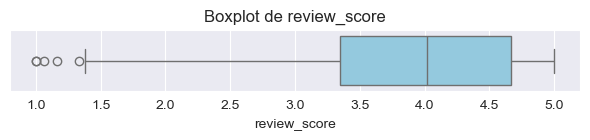

In [8]:
# Seleccionar columnas numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Crear boxplots
for col in num_cols:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f"Boxplot de {col}")
    plt.tight_layout()
    plt.show()

In [9]:
# Función para detectar outliers usando IQR
def detectar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return serie[(serie < limite_inferior) | (serie > limite_superior)]

# Mostrar conteo de outliers por variable
print("Conteo de outliers detectados por IQR:")
for col in num_cols:
    outliers = detectar_outliers_iqr(df[col])
    print(f"{col}: {len(outliers)} outliers")

Conteo de outliers detectados por IQR:
customer_id: 0 outliers
age: 9 outliers
income: 25 outliers
num_logins_last_month: 6 outliers
avg_session_time_min: 8 outliers
purchases_last_month: 18 outliers
total_spent: 20 outliers
loyalty_score: 0 outliers
days_since_last_login: 0 outliers
avg_basket_size: 5 outliers
customer_support_calls: 104 outliers
discount_usage_pct: 0 outliers
referral_count: 20 outliers
review_score: 5 outliers


In [10]:
# Eliminar outliers (aquí se eliminan filas con cualquier outlier)
df_sin_outliers = df.copy()
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_sin_outliers = df_sin_outliers[(df_sin_outliers[col] >= lower) & (df_sin_outliers[col] <= upper)]

print(f"Dimensiones originales: {df.shape}")
print(f"Dimensiones sin outliers: {df_sin_outliers.shape}")

Dimensiones originales: (1500, 22)
Dimensiones sin outliers: (1300, 22)


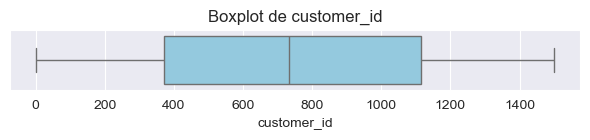

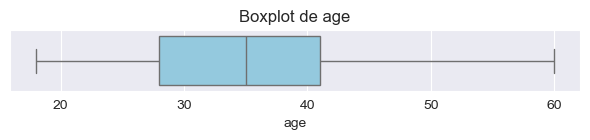

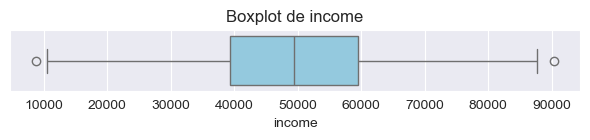

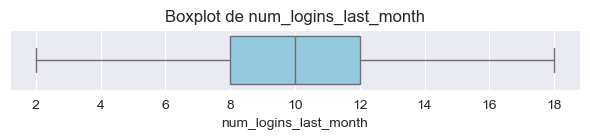

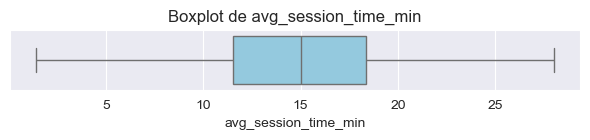

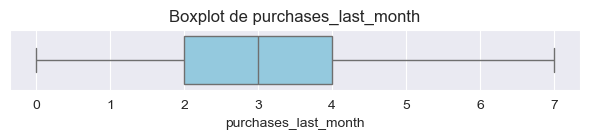

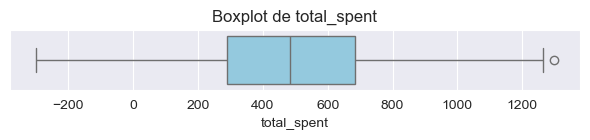

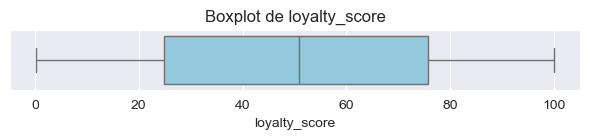

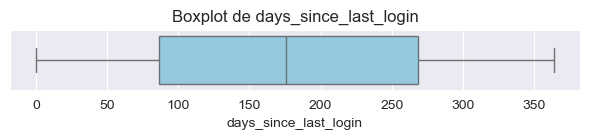

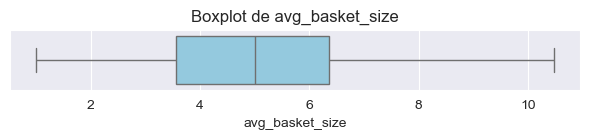

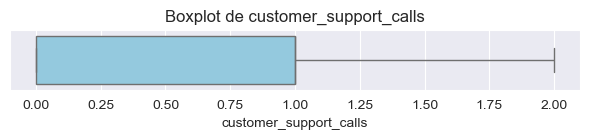

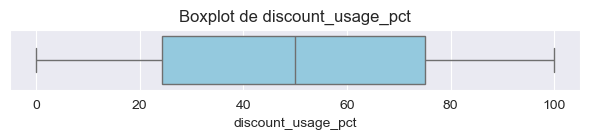

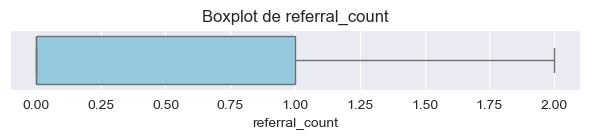

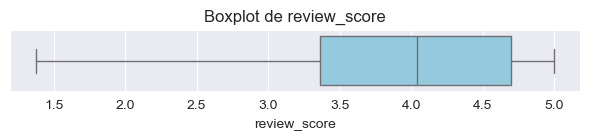

In [11]:
# Seleccionar columnas numéricas
num_cols = df_sin_outliers.select_dtypes(include=['int64', 'float64']).columns

# Crear boxplots
for col in num_cols:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(x=df_sin_outliers[col], color='skyblue')
    plt.title(f"Boxplot de {col}")
    plt.tight_layout()
    plt.show()

In [12]:
# Seleccionar variables numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Número de bins
bins = 6

# Aplicar binning por ancho
print("Binning por ancho de intervalo:")
binned_width = pd.DataFrame()
for col in num_cols:
    binned_width[col + "_bin_width"] = pd.cut(df[col], bins=bins, labels=False)
display(binned_width.sample(25))

# Aplicar binning por frecuencia (cuartiles, quintiles, etc.)
print("Binning por frecuencia (igual número de observaciones):")
binned_freq = pd.DataFrame()
for col in num_cols:
    try:
        binned_freq[col + "_bin_freq"] = pd.qcut(df[col], q=bins, labels=False, duplicates='drop')
    except ValueError:
        print(f"Saltando {col} (no se puede aplicar qcut por falta de valores únicos)")
display(binned_freq.sample(25))

Binning por ancho de intervalo:


,customer_id_bin_width,age_bin_width,income_bin_width,num_logins_last_month_bin_width,avg_session_time_min_bin_width,purchases_last_month_bin_width,total_spent_bin_width,loyalty_score_bin_width,days_since_last_login_bin_width,avg_basket_size_bin_width,customer_support_calls_bin_width,discount_usage_pct_bin_width,referral_count_bin_width,review_score_bin_width
690,2,1,0,1,2,0,2,4,3,0,1,1,1,3
1037,4,2,0,3,3,0,1,4,4,2,0,2,0,5
1170,4,1,0,1,3,2,2,3,4,1,0,2,4,1
108,0,1,0,0,3,2,1,5,0,1,0,4,0,5
84,0,1,0,1,3,1,1,4,0,2,0,1,2,3
857,3,0,0,2,3,0,2,5,4,2,2,0,1,3
202,0,2,0,1,1,0,2,1,3,0,1,0,2,4
353,1,0,0,2,3,0,2,5,3,2,0,2,1,3
314,1,1,0,2,3,0,2,0,2,1,0,4,1,5
1459,5,3,0,0,3,0,1,1,1,2,0,2,1,5


Binning por frecuencia (igual número de observaciones):


,customer_id_bin_freq,age_bin_freq,income_bin_freq,num_logins_last_month_bin_freq,avg_session_time_min_bin_freq,purchases_last_month_bin_freq,total_spent_bin_freq,loyalty_score_bin_freq,days_since_last_login_bin_freq,avg_basket_size_bin_freq,customer_support_calls_bin_freq,discount_usage_pct_bin_freq,referral_count_bin_freq,review_score_bin_freq
584,2,0,2,0,3,3,2,2,3,4,1,0,0,1
1130,4,5,4,1,5,3,1,5,5,1,0,0,0,4
468,1,2,3,3,2,1,2,2,5,5,0,2,0,3
453,1,2,0,0,0,2,3,2,4,3,0,4,0,0
433,1,4,3,4,1,5,2,0,3,4,0,0,0,1
1209,4,5,4,0,3,4,1,0,0,5,1,5,0,3
1399,5,4,2,0,3,1,1,5,1,5,0,1,0,4
1355,5,3,1,3,5,0,2,4,0,4,0,2,0,1
185,0,0,0,1,1,0,0,1,5,2,0,1,1,5
1204,4,1,2,0,0,2,1,4,3,5,0,4,0,0


In [13]:
# Extraer componentes de fecha
df['registration_year'] = df['registration_date'].dt.year
df['registration_month'] = df['registration_date'].dt.month
df['registration_day'] = df['registration_date'].dt.day
df['registration_weekday'] = df['registration_date'].dt.dayofweek  # 0=lunes

df['last_purchase_year'] = df['last_purchase_date'].dt.year
df['last_purchase_month'] = df['last_purchase_date'].dt.month
df['last_purchase_day'] = df['last_purchase_date'].dt.day
df['last_purchase_weekday'] = df['last_purchase_date'].dt.dayofweek

# Calcular diferencia en días entre fechas
df['days_between_registration_and_purchase'] = (
    (df['last_purchase_date'] - df['registration_date']).dt.days
)

# Ver las nuevas columnas derivadas
print("Variables de fecha procesadas:")
display(df[[
    'registration_date', 'last_purchase_date',
    'registration_year', 'registration_month', 'registration_day', 'registration_weekday',
    'last_purchase_year', 'last_purchase_month', 'last_purchase_day', 'last_purchase_weekday',
    'days_between_registration_and_purchase'
]].sample(25))

Variables de fecha procesadas:


,registration_date,last_purchase_date,registration_year,registration_month,registration_day,registration_weekday,last_purchase_year,last_purchase_month,last_purchase_day,last_purchase_weekday,days_between_registration_and_purchase
529,2022-08-28,2024-12-21,2022,8,28,6,2024,12,21,5,846
254,2022-06-17,2022-06-25,2022,6,17,4,2022,6,25,5,8
656,2022-02-03,2022-04-23,2022,2,3,3,2022,4,23,5,79
83,2022-07-19,2023-07-20,2022,7,19,1,2023,7,20,3,366
1266,2021-11-28,2022-01-25,2021,11,28,6,2022,1,25,1,58
527,2021-07-21,2021-08-22,2021,7,21,2,2021,8,22,6,32
284,2020-05-22,2020-06-15,2020,5,22,4,2020,6,15,0,24
778,2020-09-08,2021-04-09,2020,9,8,1,2021,4,9,4,213
334,2020-03-28,2021-08-26,2020,3,28,5,2021,8,26,3,516
858,2022-07-08,2024-08-03,2022,7,8,4,2024,8,3,5,757
